# 02 · Archive Data Pipeline — Skincare Conversation Analysis

Loads real ChatGPT conversations from the archive files, filters for skincare relevance,
extracts brand mentions, and runs the same clustering + brand-amplification pipeline
as notebook 01 (without synthetic data or NIQ ground-truth labels).

**Sources**
| File | Schema | Records |
|---|---|---|
| `chatlogs-v2.jsonl` | post_number / conversation: [{user, message}] | 89 311 |
| `fastchat_cleaned.json` | id / conversations: [{from, value}] | 52 563 |

**Pipeline**: Load → Normalize → Filter (skincare) → Brand extraction → Feature engineering → Embed → Cluster → Brand amplification → Export

In [3]:
import json, re, warnings
from collections import Counter
from dataclasses import dataclass, field
from pathlib import Path
from typing import List

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 110

DATA_DIR   = Path('../data/archive')
OUTPUT_DIR = Path('../outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

@dataclass
class Config:
    v2_path:       Path = DATA_DIR / 'chatlogs-v2.jsonl'
    fastchat_path: Path = DATA_DIR / 'fastchat_cleaned.json'

    brands: List[str] = field(default_factory=lambda: [
        'CeraVe', 'Cetaphil', 'Neutrogena', 'Olay', 'Aveeno',
        'La Roche-Posay', 'The Ordinary', "Paula's Choice",
        'Drunk Elephant', 'Tatcha', "Kiehl's", 'First Aid Beauty',
        'Vanicream', 'EltaMD', 'Differin', 'Stridex',
        'Adapalene', 'Retin-A', 'Inkey List', 'Clinique',
        'Dermalogica', 'Skinceuticals', 'SkinCeuticals',
        'Peter Thomas Roth', 'Cosrx', 'Some By Mi', 'Laneige',
        'Innisfree', 'Missha', 'COSRX',
    ])

    n_clusters:      int = 6
    embedding_model: str = 'all-MiniLM-L6-v2'
    llm_model:       str = 'claude-fable-5'
    max_rows:        int = 5000   # cap for speed; set None to use all
    random_seed:     int = 42

cfg = Config()
print(f'Config ready. Brands: {len(cfg.brands)} | max_rows: {cfg.max_rows}')

Config ready. Brands: 30 | max_rows: 5000


In [4]:
CAPS = {}
try:
    from sentence_transformers import SentenceTransformer
    CAPS['sbert'] = True
except ImportError:
    CAPS['sbert'] = False

try:
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score
    from sklearn.decomposition import TruncatedSVD
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.preprocessing import normalize
    CAPS['sklearn'] = True
except ImportError:
    CAPS['sklearn'] = False

print('Detected capabilities:')
for cap, ok in CAPS.items():
    print(f'  {"[ok]" if ok else "[missing]"} {cap}')
if not CAPS['sbert']:   print('[fallback] no sentence-transformers -- using TF-IDF + SVD')
if not CAPS['sklearn']: raise RuntimeError('scikit-learn required: pip install scikit-learn')

Detected capabilities:
  [ok] sbert
  [ok] sklearn


## §1 · Data Loading & Normalization

Each source has a different schema. We normalize to flat Q/A rows:
`session_id | session_pos | question | answer | source`

Multi-turn conversations are flattened: each Human→AI consecutive pair becomes one row.

- **chatlogs-v2.jsonl** — turns alternate `Anonymous` → `Chat GPT`
- **fastchat_cleaned.json** — turns labelled `from: human` / `from: gpt`

In [5]:
def _str(v) -> str:
    if isinstance(v, str):  return v
    if isinstance(v, list): return v[0] if v else ''
    return str(v) if v is not None else ''

def load_v2(path: Path) -> pd.DataFrame:
    rows = []
    with open(path, encoding='utf-8', errors='replace') as f:
        for line in f:
            try:   obj = json.loads(line)
            except json.JSONDecodeError: continue
            post_id = _str(obj.get('post_number', ''))
            turns   = obj.get('conversation') or obj.get('conversations') or []
            pos, i = 0, 0
            while i < len(turns) - 1:
                u0 = _str(turns[i].get('user', ''))
                u1 = _str(turns[i+1].get('user', ''))
                if 'Anonymous' in u0 and 'Chat GPT' in u1:
                    rows.append({
                        'session_id':  f'v2_{post_id}',
                        'session_pos': pos,
                        'question':    _str(turns[i].get('message', '')),
                        'answer':      _str(turns[i+1].get('message', '')),
                        'source':      'chatlogs-v2',
                    })
                    pos += 1; i += 2
                else:
                    i += 1
    return pd.DataFrame(rows)

def load_fastchat(path: Path) -> pd.DataFrame:
    with open(path, encoding='utf-8', errors='replace') as f:
        data = json.load(f)
    rows = []
    for item in data:
        item_id = item.get('id', '')
        turns   = item.get('conversations') or item.get('conversation') or []
        pos, i = 0, 0
        while i < len(turns) - 1:
            if turns[i]['from'] == 'human' and turns[i+1]['from'] == 'gpt':
                rows.append({
                    'session_id':  f'fc_{item_id}',
                    'session_pos': pos,
                    'question':    turns[i].get('value', ''),
                    'answer':      turns[i+1].get('value', ''),
                    'source':      'fastchat',
                })
                pos += 1; i += 2
            else:
                i += 1
    return pd.DataFrame(rows)

print('Loading chatlogs-v2.jsonl ...')
df_v2 = load_v2(cfg.v2_path)
print(f'  chatlogs-v2:  {len(df_v2):>8,} Q/A pairs')
print('Loading fastchat_cleaned.json ...')
df_fc = load_fastchat(cfg.fastchat_path)
print(f'  fastchat:     {len(df_fc):>8,} Q/A pairs')

df_raw = pd.concat([df_v2, df_fc], ignore_index=True)
df_raw = df_raw.dropna(subset=['question', 'answer'])
df_raw = df_raw[(df_raw['question'].str.len() > 5) & (df_raw['answer'].str.len() > 5)]
print(f'Total after cleanup: {len(df_raw):,} rows')

Loading chatlogs-v2.jsonl ...
  chatlogs-v2:   758,239 Q/A pairs
Loading fastchat_cleaned.json ...
  fastchat:      437,951 Q/A pairs
Total after cleanup: 1,161,660 rows


## §2 · Skincare Relevance Filter

Keep rows where `question` or `answer` matches a skincare keyword pattern.  
After filtering, optionally cap to `cfg.max_rows` for notebook speed.

Skincare pairs: 13,447 / 1,161,660 (1.2%)
By source:
source
chatlogs-v2    8788
fastchat       4659


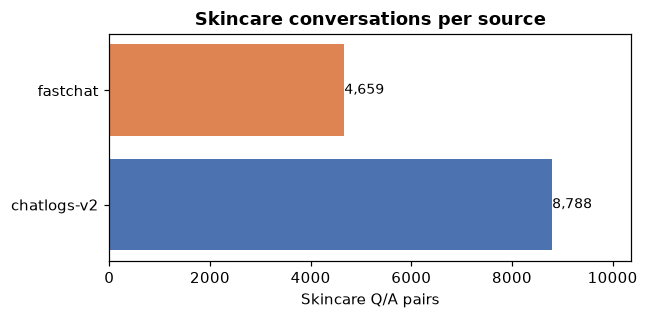

[cap] Sampled to 5,000 rows
Working dataset: 5,000 rows


In [6]:
SKIN_KEYWORDS = [
    'skincare', 'skin care', 'moisturizer', 'moisturiser', 'serum',
    'retinol', 'retinoid', 'tretinoin', 'adapalene', 'differin',
    'sunscreen', 'spf', 'sunblock',
    'acne', 'pimple', 'blackhead', 'whitehead', 'breakout', 'blemish',
    'wrinkle', 'fine line', 'anti-aging', 'anti aging',
    'hyaluronic', 'niacinamide', 'vitamin c', 'vitamin a',
    'toner', 'cleanser', 'face wash',
    'exfoliant', 'exfoliator', 'aha', 'bha', 'glycolic', 'salicylic',
    'peptide', 'collagen', 'dark spot', 'hyperpigmentation',
    'dermatologist', 'skin barrier', 'ceramide', 'purging',
    'oily skin', 'dry skin', 'combination skin', 'sensitive skin',
    'rosacea', 'eczema', 'psoriasis',
    'skin routine', 'skincare routine', 'am routine', 'pm routine',
    'eye cream', 'face cream', 'bb cream',
    'cerave', 'cetaphil', 'neutrogena', 'olay', 'aveeno',
    'la roche', 'the ordinary', "paula's choice", 'drunk elephant',
    'tatcha', 'kiehl', 'vanicream', 'cosrx', 'laneige',
]
_SKIN_PAT = re.compile('|'.join(re.escape(k) for k in SKIN_KEYWORDS), re.IGNORECASE)

mask    = df_raw['question'].str.contains(_SKIN_PAT) | df_raw['answer'].str.contains(_SKIN_PAT)
df_skin = df_raw[mask].copy().reset_index(drop=True)
print(f'Skincare pairs: {len(df_skin):,} / {len(df_raw):,} ({100*len(df_skin)/len(df_raw):.1f}%)')
print('By source:'); print(df_skin['source'].value_counts().to_string())

src_counts = df_skin['source'].value_counts()
fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.barh(src_counts.index, src_counts.values, color=['#4C72B0', '#DD8452'])
for bar, val in zip(bars, src_counts.values):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)
ax.set_xlabel('Skincare Q/A pairs')
ax.set_title('Skincare conversations per source', fontsize=12, fontweight='bold')
ax.set_xlim(0, src_counts.max() * 1.18)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'archive_source_distribution.png', bbox_inches='tight')
plt.show()

if cfg.max_rows and len(df_skin) > cfg.max_rows:
    df_skin = df_skin.sample(cfg.max_rows, random_state=cfg.random_seed).reset_index(drop=True)
    print(f'[cap] Sampled to {cfg.max_rows:,} rows')
df = df_skin.copy()
print(f'Working dataset: {len(df):,} rows')

## §3 · Brand Extraction

Match brand names from `cfg.brands` with whole-word regex.  
Produces `brands_in_question` and `brands_in_answer` list columns.

Rows with brand in question: 92 (1.8%)
Rows with brand in answer:   90 (1.8%)


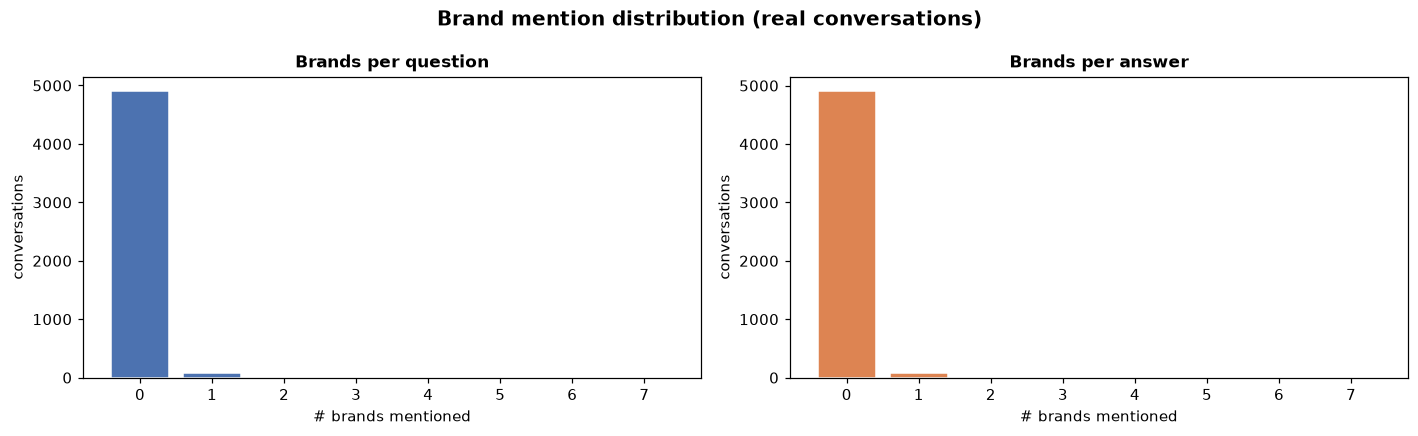

Top brands in questions: [('The Ordinary', 65), ('Neutrogena', 9), ('CeraVe', 6), ("Kiehl's", 5), ("Paula's Choice", 5), ('Retin-A', 4), ('Clinique', 3), ('Olay', 3), ('Skinceuticals', 2), ('Cosrx', 1)]
Top brands in answers:   [('The Ordinary', 63), ('La Roche-Posay', 9), ('Neutrogena', 9), ("Kiehl's", 8), ('Olay', 6), ("Paula's Choice", 5), ('Adapalene', 5), ('CeraVe', 5), ('Cetaphil', 3), ('Clinique', 2)]


In [7]:
BRAND_ALIASES = {'SkinCeuticals': 'Skinceuticals', 'COSRX': 'Cosrx'}
BRAND_PATTERNS = {}
for b in cfg.brands:
    canon = BRAND_ALIASES.get(b, b)
    if canon not in BRAND_PATTERNS:
        BRAND_PATTERNS[canon] = re.compile(r'(?i)\b' + re.escape(b) + r'\b')

def extract_brands(text: str) -> List[str]:
    if not isinstance(text, str): return []
    return sorted({b for b, pat in BRAND_PATTERNS.items() if pat.search(text)})

df['brands_in_question'] = df['question'].apply(extract_brands)
df['brands_in_answer']   = df['answer'].apply(extract_brands)
df['n_brands_q'] = df['brands_in_question'].apply(len)
df['n_brands_a'] = df['brands_in_answer'].apply(len)

print(f'Rows with brand in question: {(df.n_brands_q > 0).sum():,} ({100*(df.n_brands_q > 0).mean():.1f}%)')
print(f'Rows with brand in answer:   {(df.n_brands_a > 0).sum():,} ({100*(df.n_brands_a > 0).mean():.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title, color in zip(
    axes, ['n_brands_q', 'n_brands_a'],
    ['Brands per question', 'Brands per answer'], ['#4C72B0', '#DD8452']):
    vc = df[col].value_counts().sort_index()
    ax.bar(vc.index, vc.values, color=color, edgecolor='white')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('# brands mentioned'); ax.set_ylabel('conversations')
plt.suptitle('Brand mention distribution (real conversations)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'archive_brand_distribution.png', bbox_inches='tight')
plt.show()

all_q = Counter(b for lst in df['brands_in_question'] for b in lst)
all_a = Counter(b for lst in df['brands_in_answer']   for b in lst)
print('Top brands in questions:', all_q.most_common(10))
print('Top brands in answers:  ', all_a.most_common(10))

## §4 · Feature Engineering

- `unsolicited_brands` — brands in answer not mentioned in question
- `n_unsolicited` / `has_unsolicited` — count and flag
- `intent` — English regex priority chain
- `topic_text` — Q + first 300 chars of A for clustering

No brands in answer:    4,910  (98.2%)
Only solicited brands:      8  (0.2%)
Has unsolicited brands:    82  (1.6%)


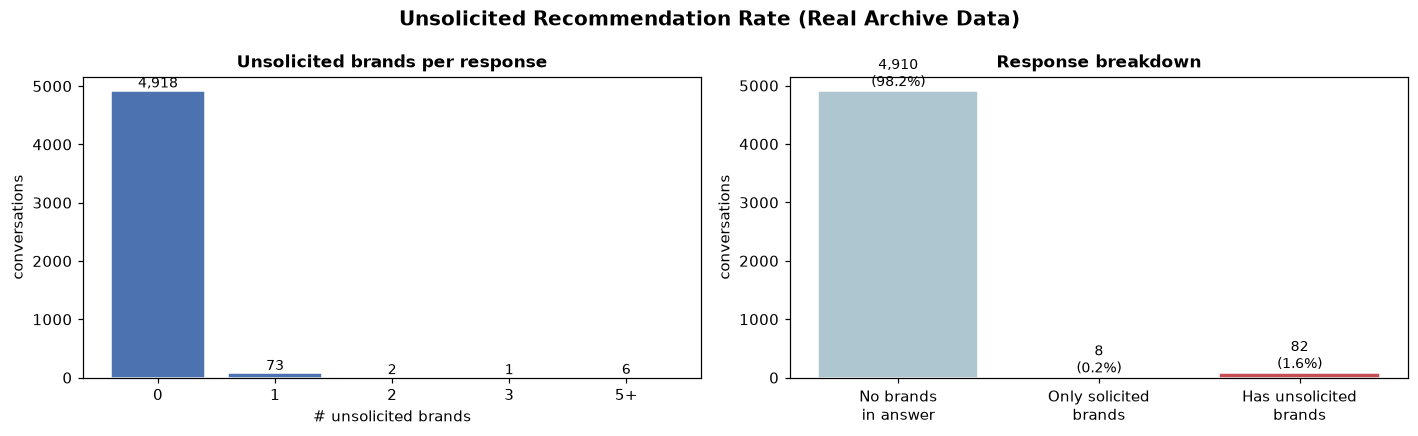

In [8]:
df['unsolicited_brands'] = df.apply(
    lambda r: sorted(set(r.brands_in_answer) - set(r.brands_in_question)), axis=1)
df['n_unsolicited']   = df['unsolicited_brands'].apply(len)
df['has_unsolicited'] = df['n_unsolicited'] > 0

total     = len(df)
no_brand  = (df.n_brands_a == 0).sum()
sol_only  = ((df.n_brands_a > 0) & ~df.has_unsolicited).sum()
has_unsol = df.has_unsolicited.sum()
print(f'No brands in answer:    {no_brand:5,}  ({100*no_brand/total:.1f}%)')
print(f'Only solicited brands:  {sol_only:5,}  ({100*sol_only/total:.1f}%)')
print(f'Has unsolicited brands: {has_unsol:5,}  ({100*has_unsol/total:.1f}%)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
n_cap = df['n_unsolicited'].clip(upper=5)
vc    = n_cap.value_counts().sort_index()
vc.index = [str(i) if i < 5 else '5+' for i in vc.index]
bars1 = ax1.bar(vc.index, vc.values, color='#4C72B0', edgecolor='white')
for bar, val in zip(bars1, vc.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{val:,}', ha='center', va='bottom', fontsize=9)
ax1.set_title('Unsolicited brands per response', fontsize=11, fontweight='bold')
ax1.set_xlabel('# unsolicited brands'); ax1.set_ylabel('conversations')

labels = ['No brands\nin answer', 'Only solicited\nbrands', 'Has unsolicited\nbrands']
bars2  = ax2.bar(labels, [no_brand, sol_only, has_unsol],
                 color=['#aec6cf', '#55A868', '#C44E52'], edgecolor='white')
for bar, val in zip(bars2, [no_brand, sol_only, has_unsol]):
    pct = 100 * val / total
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax2.set_title('Response breakdown', fontsize=11, fontweight='bold')
ax2.set_ylabel('conversations')
plt.suptitle('Unsolicited Recommendation Rate (Real Archive Data)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'archive_unsolicited_histogram.png', bbox_inches='tight')
plt.show()

Intent distribution:
intent
informational      4244
comparison          379
purchase            235
troubleshooting      81
routine              61


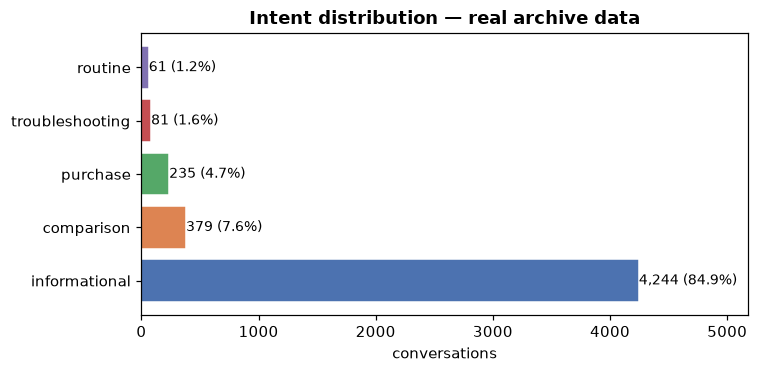

In [9]:
INTENT_PATTERNS = {
    'comparison':      [r'\bvs\b', r'\bversus\b', r'\bor\b.*\?',
                        r'which is better', r'difference between', r'compar'],
    'purchase':        [r'best product', r'what do you recommend', r'\brecommend\b',
                        r'where to buy', r'worth it', r'which one.*(buy|get)',
                        r'\bbest\b', r'dupe', r'is .* good for'],
    'troubleshooting': [r'irrit', r'got worse', r'reaction', r'broke? ?out',
                        r'can i (combine|mix)', r'side effect', r'purging',
                        r'burning', r'not working'],
    'routine':         [r'routine', r'order of application', r'morning and night',
                        r'step by step', r'\bam[/ ]pm\b', r'\blayer\b'],
    'informational':   [r'what is', r'how does', r'what does .* do',
                        r'what is .* (for|used)', r'how it works',
                        r'\bexplain\b', r'tell me about'],
}
_INTENT_RE = {intent: re.compile('|'.join(pats), re.IGNORECASE)
              for intent, pats in INTENT_PATTERNS.items()}
INTENT_ORDER = ['comparison', 'purchase', 'troubleshooting', 'routine', 'informational']

def classify_intent(q: str) -> str:
    for intent in INTENT_ORDER:
        if _INTENT_RE[intent].search(q or ''): return intent
    return 'informational'

df['intent']     = df['question'].apply(classify_intent)
df['topic_text'] = df['question'].fillna('') + ' ' + df['answer'].fillna('').str[:300]

INTENT_COLORS = {
    'informational': '#4C72B0', 'comparison': '#DD8452',
    'purchase': '#55A868', 'troubleshooting': '#C44E52', 'routine': '#8172B2',
}
intent_counts = df['intent'].value_counts()
print('Intent distribution:'); print(intent_counts.to_string())

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = [INTENT_COLORS[i] for i in intent_counts.index]
bars = ax.barh(intent_counts.index, intent_counts.values, color=colors, edgecolor='white')
for bar, val in zip(bars, intent_counts.values):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({100*val/len(df):.1f}%)', va='center', fontsize=9)
ax.set_title('Intent distribution — real archive data', fontsize=12, fontweight='bold')
ax.set_xlabel('conversations'); ax.set_xlim(0, intent_counts.max() * 1.22)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'archive_intent_distribution.png', bbox_inches='tight')
plt.show()

## §5 · Embeddings

Uses `sentence-transformers` (`all-MiniLM-L6-v2`) when installed.  
Falls back to TF-IDF + TruncatedSVD (128 dims) otherwise.

In [10]:
texts = df['topic_text'].fillna('').tolist()

if CAPS['sbert']:
    print(f'Encoding {len(texts):,} texts with {cfg.embedding_model} ...')
    model = SentenceTransformer(cfg.embedding_model)
    X     = model.encode(texts, show_progress_bar=True, batch_size=64)
    X     = normalize(X)
    method = 'SBERT'
else:
    print(f'[fallback] TF-IDF + SVD on {len(texts):,} texts ...')
    tfidf = TfidfVectorizer(max_features=10_000, ngram_range=(1, 2),
                            sublinear_tf=True, min_df=2)
    Xtf   = tfidf.fit_transform(texts)
    svd   = TruncatedSVD(n_components=128, random_state=cfg.random_seed)
    X     = normalize(svd.fit_transform(Xtf))
    method = 'TF-IDF+SVD'

print(f'Embeddings ready: {X.shape}  [{method}]')

Encoding 5,000 texts with all-MiniLM-L6-v2 ...


Batches: 100%|██████████| 79/79 [05:28<00:00,  4.16s/it]


Embeddings ready: (5000, 384)  [SBERT]


## §6 · KMeans Clustering

Sweep k = 2…10, pick best silhouette, then fit KMeans at `cfg.n_clusters`.

  k= 2  silhouette=0.0409  inertia=4,333
  k= 3  silhouette=0.0504  inertia=4,186
  k= 4  silhouette=0.0543  inertia=4,117
  k= 5  silhouette=0.0559  inertia=4,067
  k= 6  silhouette=0.0307  inertia=4,024
  k= 7  silhouette=0.0338  inertia=3,983
  k= 8  silhouette=0.0359  inertia=3,947
  k= 9  silhouette=0.0317  inertia=3,922
  k=10  silhouette=0.0355  inertia=3,897
Best k: 5  (config: 6)


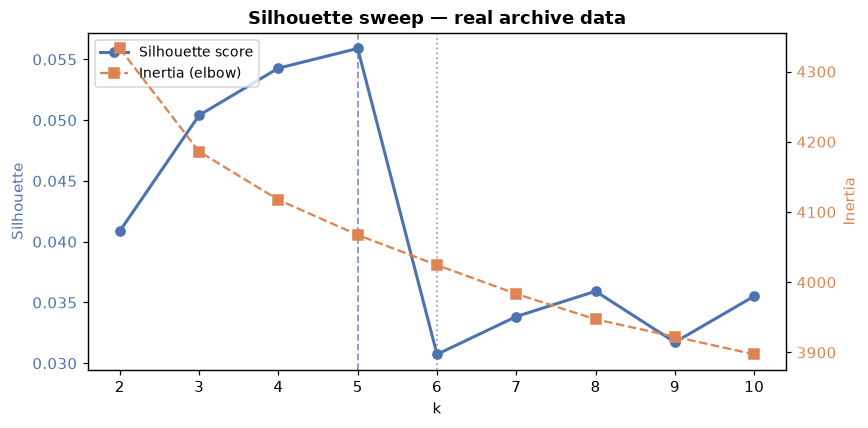

In [11]:
K_RANGE = range(2, 11)
scores, inertias = [], []
for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=cfg.random_seed, n_init=10)
    labels = km.fit_predict(X)
    sil    = silhouette_score(X, labels, sample_size=min(2000, len(X)),
                              random_state=cfg.random_seed)
    scores.append(sil); inertias.append(km.inertia_)
    print(f'  k={k:2d}  silhouette={sil:.4f}  inertia={km.inertia_:,.0f}')

best_k = list(K_RANGE)[int(np.argmax(scores))]
print(f'Best k: {best_k}  (config: {cfg.n_clusters})')

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.plot(list(K_RANGE), scores,   'o-',  color='#4C72B0', lw=2, label='Silhouette score')
ax2.plot(list(K_RANGE), inertias, 's--', color='#DD8452', lw=1.5, label='Inertia (elbow)')
ax1.axvline(best_k,         color='#4C72B0', ls='--', lw=1.2, alpha=0.7)
ax1.axvline(cfg.n_clusters, color='gray',    ls=':',  lw=1.2, alpha=0.7)
ax1.set_xlabel('k'); ax1.set_ylabel('Silhouette', color='#4C72B0')
ax2.set_ylabel('Inertia', color='#DD8452')
ax1.tick_params(axis='y', labelcolor='#4C72B0')
ax2.tick_params(axis='y', labelcolor='#DD8452')
lines1, lb1 = ax1.get_legend_handles_labels()
lines2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lb1 + lb2, loc='upper left', fontsize=9)
plt.title('Silhouette sweep — real archive data', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'archive_silhouette_sweep.png', bbox_inches='tight')
plt.show()

In [13]:
km_final = KMeans(n_clusters=cfg.n_clusters, random_state=cfg.random_seed, n_init=10)
df['cluster'] = km_final.fit_predict(X)

print(f'Cluster sizes (k={cfg.n_clusters}):')
print(df['cluster'].value_counts().sort_index().to_string())

from sklearn.feature_extraction.text import TfidfVectorizer as _TV
tfidf_lbl = _TV(max_features=5000, ngram_range=(1, 2), sublinear_tf=True, min_df=2)
Xtf_lbl   = tfidf_lbl.fit_transform(df['topic_text'].fillna(''))
terms     = tfidf_lbl.get_feature_names_out()
print('\nTop-10 terms per cluster:')
for cid in sorted(df['cluster'].unique()):
    mask_c   = df['cluster'] == cid
    centroid = Xtf_lbl[mask_c].mean(axis=0)
    top10    = ', '.join(terms[centroid.argsort()[-10:][::-1]])
    print(f'  Cluster {cid} (n={mask_c.sum():4,}): {top10}')

Cluster sizes (k=6):
cluster
0     224
1    1236
2     613
3     797
4     912
5    1218

Top-10 terms per cluster:


AttributeError: 'Series' object has no attribute 'nonzero'

## §7 · Cluster Characterisation

- **Left**: intent distribution per cluster (stacked bar)
- **Right**: unsolicited recommendation rate vs global average

Cluster summary:
         size     top_intent  unsolicited_rate  brands_per_resp
cluster                                                        
0         224  informational             0.000            0.000
1        1236  informational             0.011            0.014
2         613  informational             0.003            0.013
3         797  informational             0.026            0.063
4         912  informational             0.000            0.000
5        1218  informational             0.037            0.039


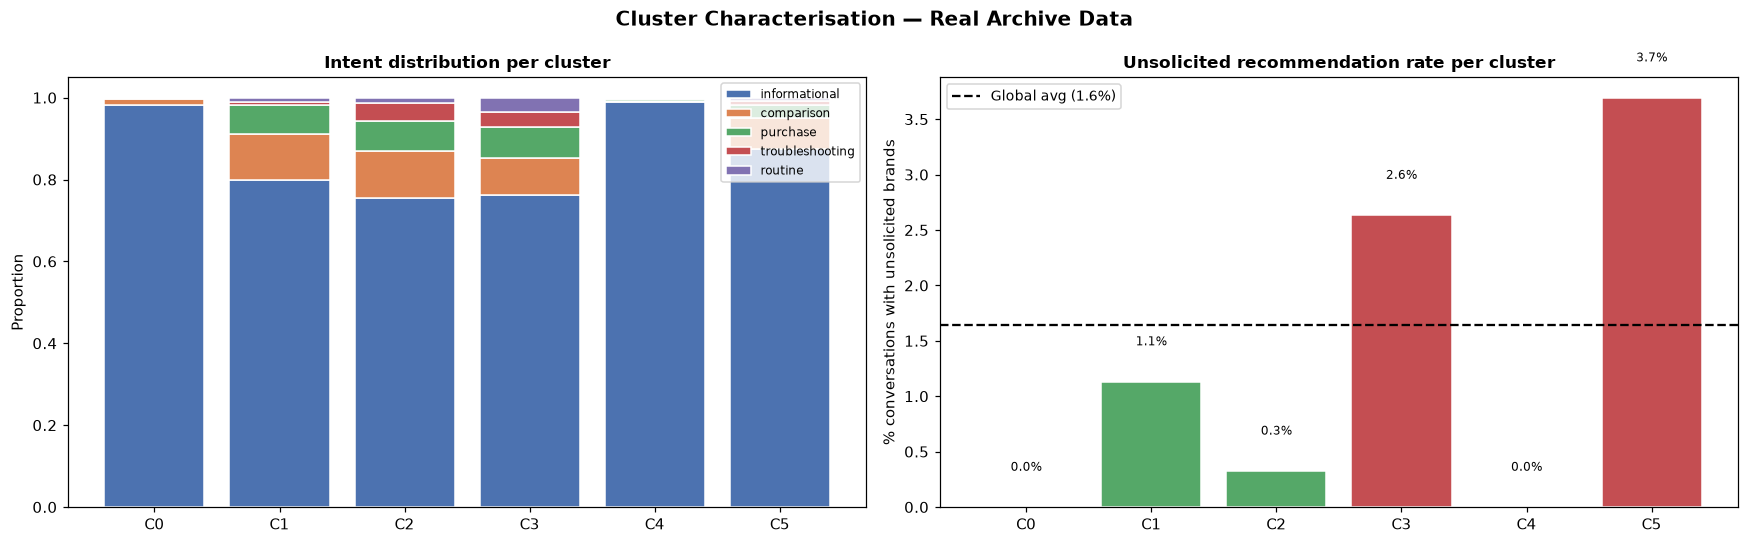

In [14]:
intents_all = ['informational', 'comparison', 'purchase', 'troubleshooting', 'routine']
intent_matrix = pd.DataFrame(index=sorted(df['cluster'].unique()),
                              columns=intents_all, dtype=float)
for cid in intent_matrix.index:
    sub = df[df['cluster'] == cid]['intent'].value_counts(normalize=True)
    for intent in intents_all:
        intent_matrix.loc[cid, intent] = sub.get(intent, 0.0)

unsol_rate        = df.groupby('cluster')['has_unsolicited'].mean()
global_unsol_rate = df['has_unsolicited'].mean()

summary = df.groupby('cluster').agg(
    size=('question', 'count'),
    top_intent=('intent', lambda x: x.value_counts().index[0]),
    unsolicited_rate=('has_unsolicited', 'mean'),
    brands_per_resp=('n_brands_a', 'mean'),
).round(3)
print('Cluster summary:'); print(summary.to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
bottoms = np.zeros(len(intent_matrix))
xticks  = [f'C{cid}' for cid in intent_matrix.index]
for intent in intents_all:
    vals = intent_matrix[intent].values.astype(float)
    ax1.bar(xticks, vals, bottom=bottoms, label=intent,
            color=INTENT_COLORS[intent], edgecolor='white')
    bottoms += vals
ax1.set_title('Intent distribution per cluster', fontsize=11, fontweight='bold')
ax1.set_ylabel('Proportion'); ax1.set_ylim(0, 1.05)
ax1.legend(loc='upper right', fontsize=8)

bar_colors = ['#C44E52' if r > global_unsol_rate else '#55A868' for r in unsol_rate]
bars = ax2.bar([f'C{c}' for c in unsol_rate.index],
               unsol_rate.values * 100, color=bar_colors, edgecolor='white')
ax2.axhline(global_unsol_rate * 100, color='black', ls='--', lw=1.5,
            label=f'Global avg ({global_unsol_rate*100:.1f}%)')
for bar, val in zip(bars, unsol_rate.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val*100:.1f}%', ha='center', va='bottom', fontsize=8)
ax2.set_title('Unsolicited recommendation rate per cluster', fontsize=11, fontweight='bold')
ax2.set_ylabel('% conversations with unsolicited brands')
ax2.legend(fontsize=9)
plt.suptitle('Cluster Characterisation — Real Archive Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'archive_cluster_characterization.png', bbox_inches='tight')
plt.show()

## §8 · Brand Amplification

**Amplification** = LLM answer-share / user question-share.  
- Red (> 1): LLM over-recommends relative to organic demand
- Blue (< 1): LLM under-recommends

Only brands with >= 3 answer appearances are shown.

         brand  q_count  a_count  q_share  a_share  amplification
      Cetaphil        0        3 0.000000 0.024390   2.439024e+07
La Roche-Posay        1        9 0.009434 0.073171   7.756100e+00
     Adapalene        1        5 0.009434 0.040650   4.308900e+00
          Olay        3        6 0.028302 0.048780   1.723600e+00
       Kiehl's        5        8 0.047170 0.065041   1.378900e+00
Paula's Choice        5        5 0.047170 0.040650   8.618000e-01
    Neutrogena        9        9 0.084906 0.073171   8.618000e-01
  The Ordinary       65       63 0.613208 0.512195   8.353000e-01
        CeraVe        6        5 0.056604 0.040650   7.182000e-01


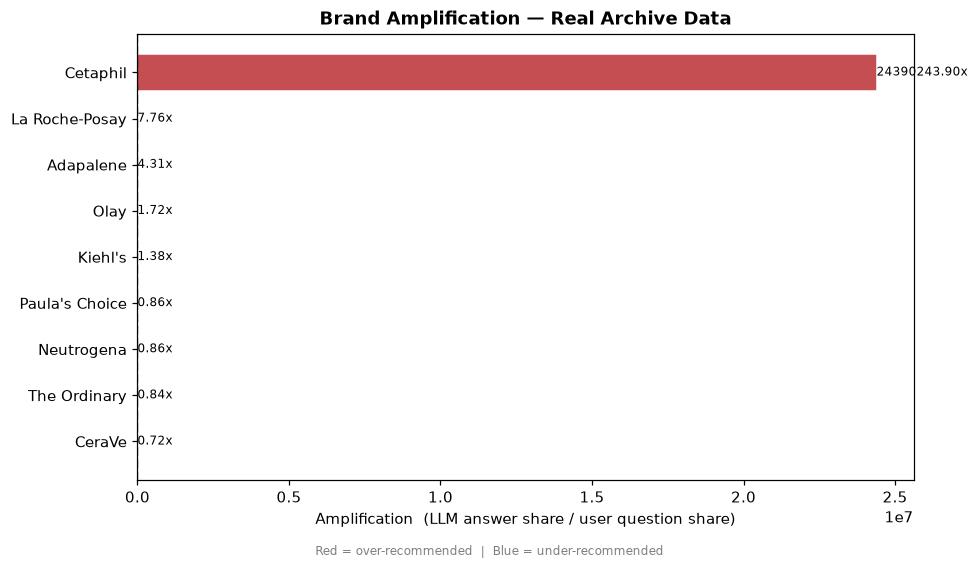

In [15]:
q_total        = df['n_brands_q'].sum()
a_total        = df['n_brands_a'].sum()
brand_q_counts = Counter(b for lst in df['brands_in_question'] for b in lst)
brand_a_counts = Counter(b for lst in df['brands_in_answer']   for b in lst)

amp_rows = []
for brand, a_count in brand_a_counts.items():
    if a_count < 3: continue
    q_count = brand_q_counts.get(brand, 0)
    q_share = q_count / max(q_total, 1)
    a_share = a_count / max(a_total, 1)
    amp     = a_share / max(q_share, 1e-9)
    amp_rows.append({'brand': brand, 'q_count': q_count, 'a_count': a_count,
                     'q_share': round(q_share, 6), 'a_share': round(a_share, 6),
                     'amplification': round(amp, 4)})

amp_df = pd.DataFrame(amp_rows).sort_values('amplification', ascending=False)
print(amp_df.to_string(index=False))

plot_amp = amp_df.sort_values('amplification')
fig, ax  = plt.subplots(figsize=(9, max(5, len(plot_amp) * 0.5)))
colors   = ['#C44E52' if v > 1.0 else '#4C72B0' for v in plot_amp['amplification']]
bars     = ax.barh(plot_amp['brand'], plot_amp['amplification'],
                   color=colors, edgecolor='white')
ax.axvline(1.0, color='black', ls='--', lw=1.5)
for bar, val in zip(bars, plot_amp['amplification']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}x', va='center', ha='left', fontsize=8)
ax.set_xlabel('Amplification  (LLM answer share / user question share)')
ax.set_title('Brand Amplification — Real Archive Data', fontsize=12, fontweight='bold')
ax.set_xlim(left=0)
fig.text(0.5, -0.02, 'Red = over-recommended  |  Blue = under-recommended',
         ha='center', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'archive_brand_amplification.png', bbox_inches='tight')
plt.show()

## §9 · Top Unsolicited Recommendations

Which brands does the LLM introduce most when the user did NOT mention them?

         brand  times_recommended
  The Ordinary                 57
La Roche-Posay                  9
    Neutrogena                  9
       Kiehl's                  8
          Olay                  6
     Adapalene                  5
Paula's Choice                  3
      Cetaphil                  3
        CeraVe                  3
      Clinique                  2
 Skinceuticals                  2
         Cosrx                  1
    Inkey List                  1
   Dermalogica                  1
Drunk Elephant                  1


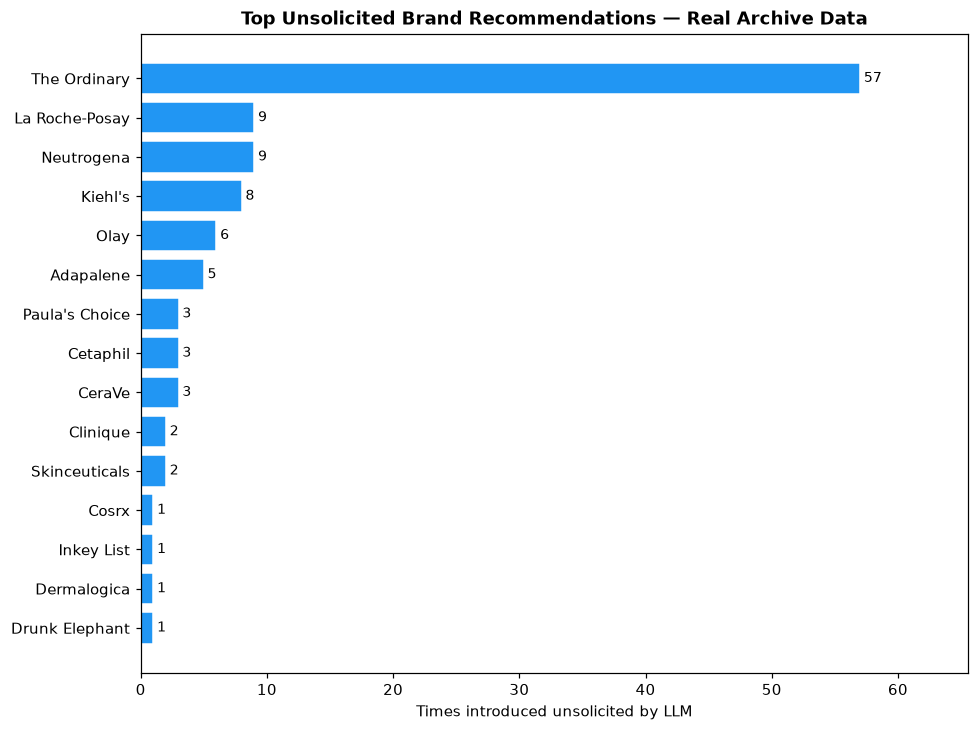

Top-3 unsolicited per cluster:
  Cluster 0: (none)
  Cluster 1: The Ordinary(13), Adapalene(1)
  Cluster 2: Cosrx(1), Inkey List(1), Kiehl's(1)
  Cluster 3: La Roche-Posay(8), Neutrogena(8), Kiehl's(7)
  Cluster 4: (none)
  Cluster 5: The Ordinary(42), Adapalene(3)


In [16]:
unsol_counter = Counter(b for lst in df['unsolicited_brands'] for b in lst)
top15 = pd.DataFrame(unsol_counter.most_common(15),
                     columns=['brand', 'times_recommended'])
print(top15.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, max(4, len(top15) * 0.45)))
bars = ax.barh(top15['brand'][::-1], top15['times_recommended'][::-1],
               color='#2196F3', edgecolor='white')
for bar, val in zip(bars, top15['times_recommended'][::-1]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
ax.set_xlabel('Times introduced unsolicited by LLM')
ax.set_title('Top Unsolicited Brand Recommendations — Real Archive Data',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, top15['times_recommended'].max() * 1.15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'archive_top_unsolicited.png', bbox_inches='tight')
plt.show()

print('Top-3 unsolicited per cluster:')
for cid in sorted(df['cluster'].unique()):
    sub  = df[df['cluster'] == cid]
    c    = Counter(b for lst in sub['unsolicited_brands'] for b in lst)
    top3 = ', '.join(f'{b}({n})' for b, n in c.most_common(3))
    print(f'  Cluster {cid}: {top3 or "(none)"}')

## §10 · Export

In [ ]:
export_df = df.copy()
for col in ['brands_in_question', 'brands_in_answer', 'unsolicited_brands']:
    export_df[col] = export_df[col].apply(lambda x: ', '.join(x) if x else '')

csv_path = OUTPUT_DIR / 'archive_skincare_pipeline.csv'
export_df.to_csv(csv_path, index=False)
print(f'[export] {csv_path}  ({len(export_df):,} rows)')

amp_path = OUTPUT_DIR / 'archive_brand_amplification.csv'
amp_df.to_csv(amp_path, index=False)
print(f'[export] {amp_path}  ({len(amp_df)} brands)')

print('PNG charts saved:')
for png in sorted(OUTPUT_DIR.glob('archive_*.png')):
    print(f'  {png.name}')

[export] ..\outputs\archive_skincare_pipeline.csv  (5,000 rows)
[export] ..\outputs\archive_brand_amplification.csv  (9 brands)
PNG charts saved:
  archive_brand_amplification.png
  archive_brand_distribution.png
  archive_cluster_characterization.png
  archive_intent_distribution.png
  archive_silhouette_sweep.png
  archive_source_distribution.png
  archive_top_unsolicited.png
  archive_unsolicited_histogram.png


: 

## §11 · Notes & Limitations

| Item | Detail |
|---|---|
| **Brand coverage** | Only brands in `cfg.brands` are detected. Extend the list for better recall. |
| **No ground-truth categories** | NIQ taxonomy validation skipped — archive has no `skin_care_categories` column. |
| **Multi-turn context** | Each Q/A pair is independent; brand carry-over across turns is not modelled. |
| **High amplification** | Brands absent from questions but frequent in answers get very high amplification. Cap or filter as needed. |
| **fastchat role order** | Some fastchat records start with `gpt`; the loader skips them (no matching `human->gpt` pair). |
| **max_rows cap** | Default `cfg.max_rows=5000`. Set to `None` to process all ~4 800 skincare rows. |
| **chatlogs v1 skipped** | `chatlogs.jsonl` (v1) contains the same posts as v2 in an older schema — skipped to avoid duplicates. |
| **Compatibility** | The exported CSV matches the schema of `01_text_clustering_pipeline.ipynb` and can be placed at `data/conversations.csv`. |